# Übung 10

**Gruppenname:**

*Name Ihrer Gruppe*

Gehen Sie wie folgt vor:

1. Kopieren Sie jetzt dieses Jupyter Notebook in Ihren Ordner (`Abgaben/Team_WXYZ`)

2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Falls Sie das Notebook im Browser bearbeiten, vergessen Sie nicht, es regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

### In dieser Übung ...

... werden wir intensiv mit einem Datensatz arbeiten und uns mit ihm vertraut machen.

### 10.1 Datenaufbereitung (Corona Pandemie)

In dieser Übungsaufgabe wird es darum gehen, weitere Praxiserfahrung bei der Datenaufbereitung zu sammeln. Wie Sie im Rahmen der Veranstaltung gelernt haben, lässt sich Datenaufbereitung nur schwer auf Vorlesungsfolien vermitteln, sondern muss praktisch geübt werden. Sie werden Daten der Corona-Pandemie analysieren. Die Daten stammen vom Robert Koch Institut.

- Ziel dieser Übung ist es, den Datensatz des Robert Koch Instituts so aufzubereiten, dass Sie am Ende einen Pandas DataFrame vorliegen haben, der die Anzahl Neuinfizierter pro Tag und Bundesland enthält.

**Ihre Aufgaben**


(1) Da der Datensatz des Robert Koch Instituts mittlerweile leider nicht mehr online verfügbar ist, haben wir Ihnen [hier](https://data.bialonski.de/ds/RKI_COVID-19.zip) einen Export der Daten (aus dem März 2022) hinterlegt.

- Die heruntergeladene Datei ist mehrere hundert Megabytes groß. Um Plattenplatz zu sparen, ist es empfehlenswert, die Datei in ihrem gezippten Format zu belassen. Die Pandas-Bibliothek, mit der wir die Daten später untersuchen werden, kann [gezippte Dateien direkt importieren](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html).


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/RKI_COVID-19.csv")

(3) Untersuchen Sie den importierten DataFrame:

- Welche Spalten weist der DataFrame auf?
- Welche Information enthält eine Zeile des DataFrames? Jede Zeile ist eine Meldung über einen oder mehrere Fälle von COVID-19.
- In welcher Spalte ist die Information über die Anzahl der Neuinfizierten enthalten? In der Spalte `AnzahlFall`.

In [4]:
n_samples, m_features = df.shape
cols = df.columns

print(f"N samples: {n_samples}")
print(f"M features: {m_features}")
print(cols)

df.head(5)

N samples: 4447964
M features: 18
Index(['IdBundesland', 'Bundesland', 'IdLandkreis', 'Landkreis',
       'Altersgruppe', 'Altersgruppe2', 'Geschlecht', 'Meldedatum', 'Refdatum',
       'IstErkrankungsbeginn', 'NeuerFall', 'NeuerTodesfall', 'NeuGenesen',
       'AnzahlFall', 'AnzahlTodesfall', 'AnzahlGenesen', 'Datenstand',
       'ObjectId'],
      dtype='object')


,IdBundesland,Bundesland,IdLandkreis,Landkreis,Altersgruppe,Altersgruppe2,Geschlecht,Meldedatum,Refdatum,IstErkrankungsbeginn,NeuerFall,NeuerTodesfall,NeuGenesen,AnzahlFall,AnzahlTodesfall,AnzahlGenesen,Datenstand,ObjectId
0,1,Schleswig-Holstein,1001,SK Flensburg,A05-A14,Nicht übermittelt,W,2022/01/14 00:00:00+00,2022/01/12 00:00:00+00,1,0,-9,0,1,0,1,"22.03.2022, 00:00 Uhr",1
1,1,Schleswig-Holstein,1001,SK Flensburg,A00-A04,Nicht übermittelt,M,2020/09/30 00:00:00+00,2020/09/30 00:00:00+00,0,0,-9,0,1,0,1,"22.03.2022, 00:00 Uhr",2
2,1,Schleswig-Holstein,1001,SK Flensburg,A05-A14,Nicht übermittelt,W,2022/01/14 00:00:00+00,2022/01/13 00:00:00+00,1,0,-9,0,1,0,1,"22.03.2022, 00:00 Uhr",3
3,1,Schleswig-Holstein,1001,SK Flensburg,A05-A14,Nicht übermittelt,W,2022/01/14 00:00:00+00,2022/01/14 00:00:00+00,0,0,-9,0,2,0,2,"22.03.2022, 00:00 Uhr",4
4,1,Schleswig-Holstein,1001,SK Flensburg,A00-A04,Nicht übermittelt,M,2020/10/29 00:00:00+00,2020/10/29 00:00:00+00,0,0,-9,0,1,0,1,"22.03.2022, 00:00 Uhr",5


(4) Setzen Sie die Spalte `Meldedatum` auf den Typ datetime Index.

In [6]:
df["Meldedatum"] = pd.to_datetime(df["Meldedatum"])

df

,IdBundesland,Bundesland,IdLandkreis,Landkreis,Altersgruppe,Altersgruppe2,Geschlecht,Meldedatum,Refdatum,IstErkrankungsbeginn,NeuerFall,NeuerTodesfall,NeuGenesen,AnzahlFall,AnzahlTodesfall,AnzahlGenesen,Datenstand,ObjectId
0,1,Schleswig-Holstein,1001,SK Flensburg,A05-A14,Nicht übermittelt,W,2022-01-14 00:00:00+00:00,2022/01/12 00:00:00+00,1,0,-9,0,1,0,1,"22.03.2022, 00:00 Uhr",1
1,1,Schleswig-Holstein,1001,SK Flensburg,A00-A04,Nicht übermittelt,M,2020-09-30 00:00:00+00:00,2020/09/30 00:00:00+00,0,0,-9,0,1,0,1,"22.03.2022, 00:00 Uhr",2
2,1,Schleswig-Holstein,1001,SK Flensburg,A05-A14,Nicht übermittelt,W,2022-01-14 00:00:00+00:00,2022/01/13 00:00:00+00,1,0,-9,0,1,0,1,"22.03.2022, 00:00 Uhr",3
3,1,Schleswig-Holstein,1001,SK Flensburg,A05-A14,Nicht übermittelt,W,2022-01-14 00:00:00+00:00,2022/01/14 00:00:00+00,0,0,-9,0,2,0,2,"22.03.2022, 00:00 Uhr",4
4,1,Schleswig-Holstein,1001,SK Flensburg,A00-A04,Nicht übermittelt,M,2020-10-29 00:00:00+00:00,2020/10/29 00:00:00+00,0,0,-9,0,1,0,1,"22.03.2022, 00:00 Uhr",5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4447959,16,Thüringen,16077,LK Altenburger Land,unbekannt,Nicht übermittelt,W,2022-02-17 00:00:00+00:00,2022/02/17 00:00:00+00,0,0,-9,0,1,0,1,"22.03.2022, 00:00 Uhr",4447960
4447960,16,Thüringen,16077,LK Altenburger Land,unbekannt,Nicht übermittelt,W,2022-02-26 00:00:00+00:00,2022/02/26 00:00:00+00,0,0,-9,-9,1,0,0,"22.03.2022, 00:00 Uhr",4447961
4447961,16,Thüringen,16077,LK Altenburger Land,unbekannt,Nicht übermittelt,W,2022-03-08 00:00:00+00:00,2022/03/08 00:00:00+00,0,0,-9,-9,2,0,0,"22.03.2022, 00:00 Uhr",4447962
4447962,16,Thüringen,16077,LK Altenburger Land,unbekannt,Nicht übermittelt,W,2022-03-18 00:00:00+00:00,2022/03/18 00:00:00+00,0,0,-9,-9,3,0,0,"22.03.2022, 00:00 Uhr",4447963


(5) Erstellen Sie aus dem alten DataFrame einen neuen DataFrame `covid`, der folgende Spalten enthält:

- Erste Spalte: `Meldedatum`
- 16 weitere Spalten, die jeweils nach einem Bundesland benannt sind
- letzte Spalte: `Deutschland`

Der DataFrame enthält also die Anzahl der Neuinfizierten pro Tag (Meldedatum) und Bundesland sowie für die gesamte Bundesrepublik (Spalte Deutschland).

- Beachten Sie: Ggf. benötigen Sie für die Lösung dieser Teilaufgabe etwas mehr Zeit und müssen in der Pandas Dokumentation recherchieren.

In [43]:
bl = np.unique(df["Bundesland"])

covid = df.pivot_table(index="Meldedatum", columns="Bundesland", values="AnzahlFall", aggfunc="sum").fillna(0)
covid["Deutschland"] = covid.sum(axis=1)

covid

Bundesland,Baden-Württemberg,Bayern,Berlin,Brandenburg,Bremen,Hamburg,Hessen,Mecklenburg-Vorpommern,Niedersachsen,Nordrhein-Westfalen,Rheinland-Pfalz,Saarland,Sachsen,Sachsen-Anhalt,Schleswig-Holstein,Thüringen,Deutschland
Meldedatum,,,,,,,,,,,,,,,,,
2020-01-02 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2020-01-05 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2020-01-23 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2020-01-28 00:00:00+00:00,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2020-01-29 00:00:00+00:00,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-03-17 00:00:00+00:00,41375.0,54399.0,7054.0,7952.0,1621.0,4250.0,16223.0,7729.0,28572.0,49822.0,13386.0,3959.0,19813.0,9144.0,8073.0,8397.0,281769.0
2022-03-18 00:00:00+00:00,37639.0,45522.0,5501.0,5858.0,1203.0,3188.0,14238.0,6213.0,24157.0,38643.0,10266.0,3326.0,14830.0,7068.0,7185.0,7169.0,232006.0
2022-03-19 00:00:00+00:00,19613.0,29560.0,413.0,1291.0,857.0,1465.0,6608.0,4083.0,14586.0,18545.0,3591.0,2734.0,7402.0,4097.0,3660.0,4519.0,123024.0


(6) Visualisieren Sie die Anzahl der Neuinfizierten in Nordrhein-Westfalen sowie in der gesamten Bundesrepublik als Funktion der Zeit.

- Die x-Achse ist mit "Meldedatum" beschriftet.
- Auf der x-Achse stehen Datumsangaben (z.B: '2020-03-17'), keine bloßen Integers.
- Der Titel der Abbildung lautet "Anzahl Neuinfektionen".

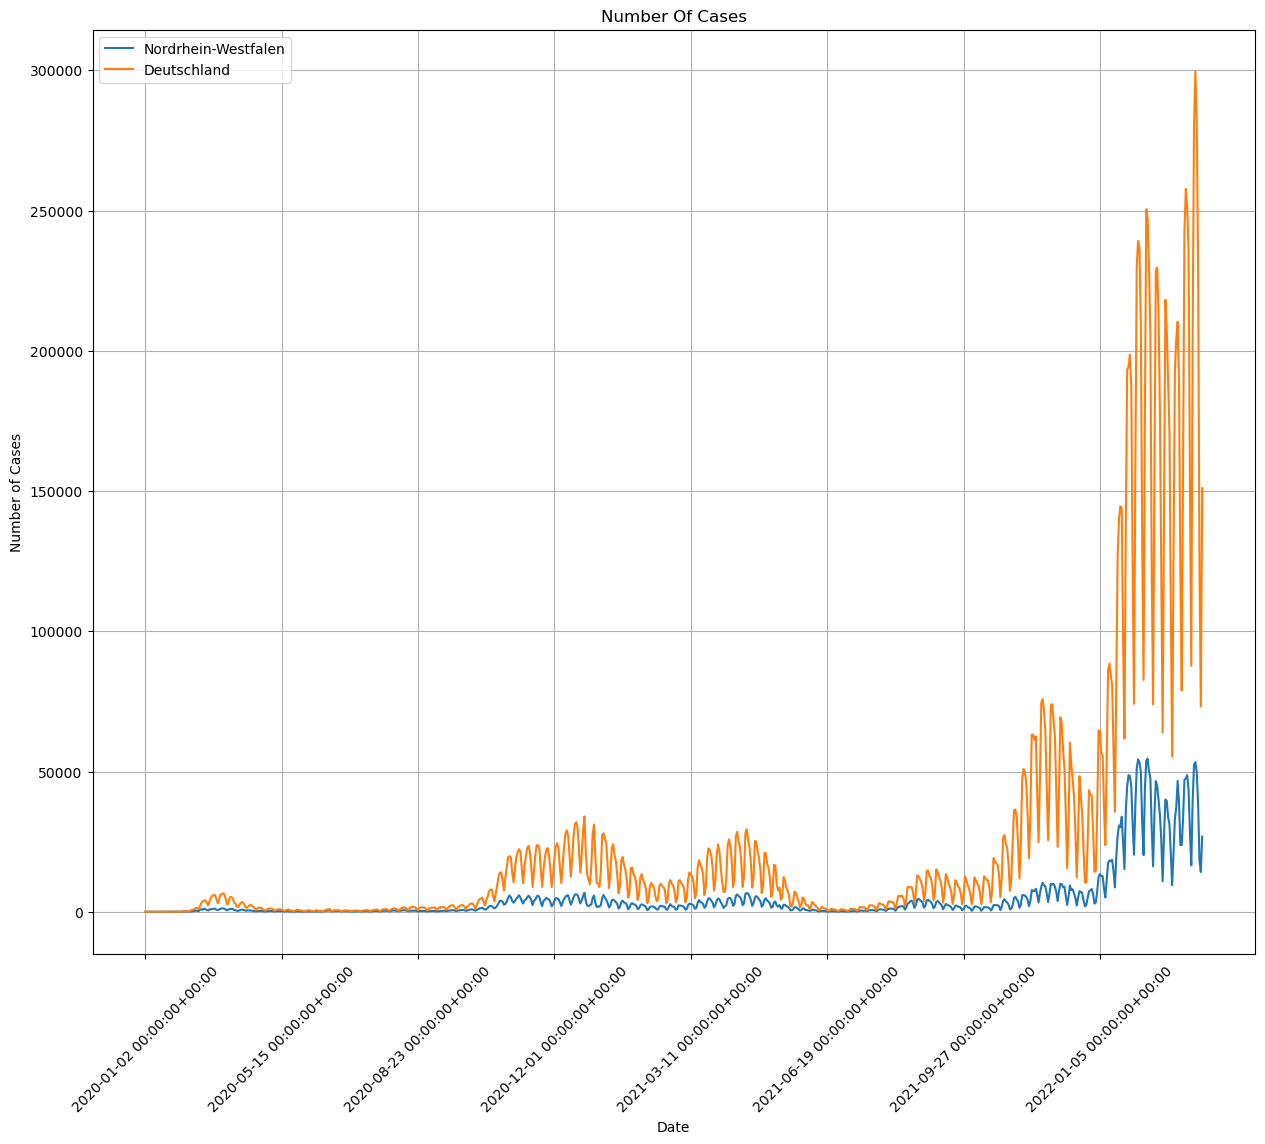

In [50]:
n_samples, m_features = covid.shape
labels = covid.index.to_list() 

plt.figure(figsize=(15, 12))

X = np.arange(n_samples)
X_tick = [X[i]for i in range(0, n_samples, 100)]
labels = [labels[i] for i in X_tick]

Y_1 = covid["Nordrhein-Westfalen"] 
Y_2 = covid["Deutschland"] 

plt.plot(X, Y_1, label="Nordrhein-Westfalen")
plt.plot(X, Y_2, label="Deutschland")
plt.title("Number Of Cases")
plt.xlabel("Date")
plt.xticks(X_tick, labels=labels, rotation=45)
plt.ylabel("Number of Cases")
plt.grid(True)
plt.legend()

### 10.2 Exploration (Corona Pandemie)

Sie werden die Daten aus der vorangegangenen Aufgabe in dieser Aufgabe analysieren.

- Diese Aufgabe ist freier gehalten als die vorangegangene Aufgabe.


**Schritte**

(1) Importieren Sie die Daten.

(2) Untersuchen Sie die Daten: **Erzeugen Sie Fragen** an die Daten und notieren Sie sie hier.

(3) **Untersuchen** Sie Ihre Fragen mit den angegebenen Daten und **visualisieren** Sie bzw. **beschreiben** Sie Ihre Erkenntnisse.

- Hinweis: Sie können gerne weitere Datenquellen aus dem Internet hinzuziehen. Geben Sie in diesem Falle Ihre Datenquellen hier an.
